In [1]:
import pandas as pd
import pyarrow as pa

# 1. GoEmotions dataset

In [2]:
file_path = r"..\data\goemotions_simplified\test\data-00000-of-00001.arrow"

# Open the file as a stream and convert to Pandas
with pa.memory_map(file_path, 'rb') as source:
    table = pa.ipc.open_stream(source).read_all()
    
test_df = table.to_pandas()

print(test_df.head())

                                                text labels       id
0  I’m really sorry about your situation :( Altho...   [25]  eecwqtt
1    It's wonderful because it's awful. At not with.    [0]  ed5f85d
2  Kings fan here, good luck to you guys! Will be...   [13]  een27c3
3  I didn't know that, thank you for teaching me ...   [15]  eelgwd1
4  They got bored from haunting earth for thousan...   [27]  eem5uti


In [3]:
file_path = r"..\data\goemotions_simplified\train\data-00000-of-00001.arrow"

# Open the file as a stream and convert to Pandas
with pa.memory_map(file_path, 'rb') as source:
    table = pa.ipc.open_stream(source).read_all()
    
train_df = table.to_pandas()

print(train_df.head())

                                                text labels       id
0  My favourite food is anything I didn't have to...   [27]  eebbqej
1  Now if he does off himself, everyone will thin...   [27]  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING    [2]  eezlygj
3                        To make her feel threatened   [14]  ed7ypvh
4                             Dirty Southern Wankers    [3]  ed0bdzj


In [4]:
file_path = r"..\data\goemotions_simplified\validation\data-00000-of-00001.arrow"

# Open the file as a stream and convert to Pandas
with pa.memory_map(file_path, 'rb') as source:
    table = pa.ipc.open_stream(source).read_all()
    
validation_df = table.to_pandas()

print(validation_df.head())

                                                text   labels       id
0  Is this in New Orleans?? I really feel like th...     [27]  edgurhb
1  You know the answer man, you are programmed to...  [4, 27]  ee84bjg
2               I've never been this sad in my life!     [25]  edcu99z
3  The economy is heavily controlled and subsidiz...  [4, 27]  edc32e2
4  He could have easily taken a real camera from ...     [20]  eepig6r


All three GoEmotions splits load with the same schema: `text`, `labels`, and `id`.

In [5]:
goemotions_df = pd.concat([train_df, validation_df, test_df], ignore_index=True).drop(columns=["id"])
goemotions_df

,text,labels
0,My favourite food is anything I didn't have to...,[27]
1,"Now if he does off himself, everyone will thin...",[27]
2,WHY THE FUCK IS BAYLESS ISOING,[2]
3,To make her feel threatened,[14]
4,Dirty Southern Wankers,[3]
...,...,...
54258,Thanks. I was diagnosed with BP 1 after the ho...,[15]
54259,Well that makes sense.,[4]
54260,Daddy issues [NAME],[27]
54261,So glad I discovered that subreddit a couple m...,[0]


The merged GoEmotions table has 54,263 examples. Keeping only `text` and `labels` keeps the analysis focused on labels and text length.

In [6]:
# emotion list
emotion_list = ["admiration", "amusement", "anger", "annoyance", "approval", "caring", "confusion", "curiosity", "desire", "disappointment", "disapproval", "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief", "joy", "love", "nervousness", "optimism", "pride", "realization", "relief", "remorse", "sadness", "surprise", "neutral"]

In [7]:
# add a column to the dataframe with the name of the emotion

for em in emotion_list:
    goemotions_df[em] = goemotions_df["labels"].apply(lambda x: 1 if emotion_list.index(em) in x else 0)

goemotions_df.head(15)

,text,labels,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,My favourite food is anything I didn't have to...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,"Now if he does off himself, everyone will thin...",[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,WHY THE FUCK IS BAYLESS ISOING,[2],0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,To make her feel threatened,[14],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Dirty Southern Wankers,[3],0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,[26],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
6,Yes I heard abt the f bombs! That has to be wh...,[15],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,We need more boards and to create a bit more s...,"[8, 20]",0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
8,Damn youtube and outrage drama is super lucrat...,[0],1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,It might be linked to the trust factor of your...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


The emotion IDs were converted into one-hot columns, which makes per-emotion counts and correlations easier to compute.

In [8]:
# add a column to the dataframe with the number of emotions present in the label column
goemotions_df["num_emotions"] = goemotions_df["labels"].apply(lambda x: len(x))

In [9]:
goemotions_df.head(15)

,text,labels,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,num_emotions
0,My favourite food is anything I didn't have to...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,"Now if he does off himself, everyone will thin...",[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,WHY THE FUCK IS BAYLESS ISOING,[2],0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,To make her feel threatened,[14],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,Dirty Southern Wankers,[3],0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,[26],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
6,Yes I heard abt the f bombs! That has to be wh...,[15],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,We need more boards and to create a bit more s...,"[8, 20]",0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
8,Damn youtube and outrage drama is super lucrat...,[0],1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,It might be linked to the trust factor of your...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [10]:
# count the number of rows in goemotions_df where the emotion column is 1
emotion_counts = {}
for emotion in emotion_list:
    emotion_counts[emotion] = goemotions_df[emotion].sum()

emotion_counts

{'admiration': np.int64(5122),
 'amusement': np.int64(2895),
 'anger': np.int64(1960),
 'annoyance': np.int64(3093),
 'approval': np.int64(3687),
 'caring': np.int64(1375),
 'confusion': np.int64(1673),
 'curiosity': np.int64(2723),
 'desire': np.int64(801),
 'disappointment': np.int64(1583),
 'disapproval': np.int64(2581),
 'disgust': np.int64(1013),
 'embarrassment': np.int64(375),
 'excitement': np.int64(1052),
 'fear': np.int64(764),
 'gratitude': np.int64(3372),
 'grief': np.int64(96),
 'joy': np.int64(1785),
 'love': np.int64(2576),
 'nervousness': np.int64(208),
 'optimism': np.int64(1976),
 'pride': np.int64(142),
 'realization': np.int64(1382),
 'relief': np.int64(182),
 'remorse': np.int64(669),
 'sadness': np.int64(1625),
 'surprise': np.int64(1330),
 'neutral': np.int64(17772)}

Neutral is by far the largest label with 17,772 examples. Among emotions, admiration, approval, gratitude, and annoyance are the most frequent.

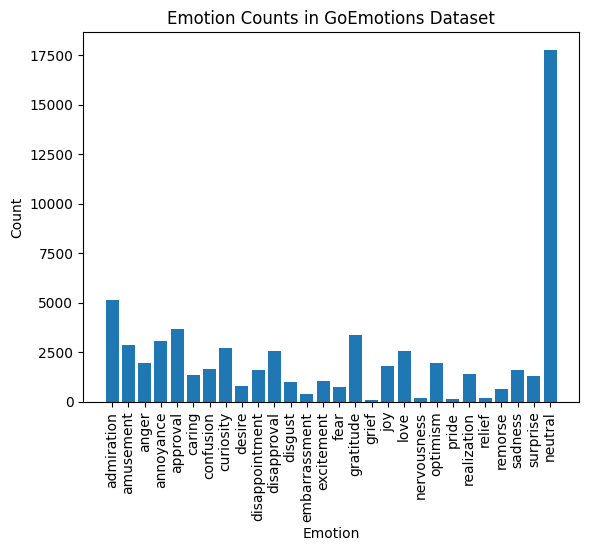

In [11]:
# plot a histogram of the emotion counts using matplotlib
import matplotlib.pyplot as plt
plt.bar(emotion_counts.keys(), emotion_counts.values())
plt.xticks(rotation=90)
plt.title("Emotion Counts in GoEmotions Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

The bar chart confirms strong label imbalance, mostly driven by the neutral class.

In [12]:
# neutral count
neutral_count = emotion_counts["neutral"]
neutral_count

np.int64(17772)

Neutral alone accounts for 17,772 annotations, making it the dominant category.

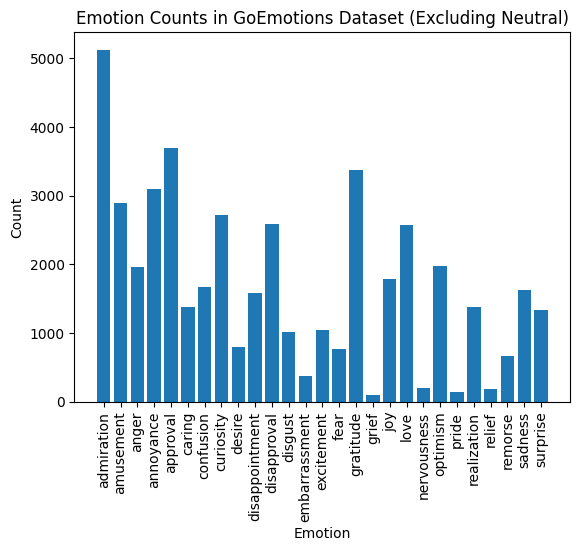

In [13]:
# plot a histogram of the emotion counts using matplotlib excluding last one (neutral)
emotion_counts_excluding_neutral = {k: v for k, v in emotion_counts.items() if k != 'neutral'}
plt.bar(emotion_counts_excluding_neutral.keys(), emotion_counts_excluding_neutral.values())
plt.xticks(rotation=90)
plt.title("Emotion Counts in GoEmotions Dataset (Excluding Neutral)")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

Removing neutral makes the imbalance among the remaining emotions easier to inspect.

In [14]:
# sort in descending order
emotion_counts_excluding_neutral_sorted = dict(sorted(emotion_counts_excluding_neutral.items(), key=lambda item: item[1], reverse=True))
emotion_counts_excluding_neutral_sorted

{'admiration': np.int64(5122),
 'approval': np.int64(3687),
 'gratitude': np.int64(3372),
 'annoyance': np.int64(3093),
 'amusement': np.int64(2895),
 'curiosity': np.int64(2723),
 'disapproval': np.int64(2581),
 'love': np.int64(2576),
 'optimism': np.int64(1976),
 'anger': np.int64(1960),
 'joy': np.int64(1785),
 'confusion': np.int64(1673),
 'sadness': np.int64(1625),
 'disappointment': np.int64(1583),
 'realization': np.int64(1382),
 'caring': np.int64(1375),
 'surprise': np.int64(1330),
 'excitement': np.int64(1052),
 'disgust': np.int64(1013),
 'desire': np.int64(801),
 'fear': np.int64(764),
 'remorse': np.int64(669),
 'embarrassment': np.int64(375),
 'nervousness': np.int64(208),
 'relief': np.int64(182),
 'pride': np.int64(142),
 'grief': np.int64(96)}

The most frequent non-neutral labels are admiration, approval, gratitude, annoyance, and amusement. Rare classes include grief, pride, relief, and nervousness.

In [15]:
# summary of num_emotions column
goemotions_df['num_emotions'].describe()

count    54263.000000
mean         1.175976
std          0.416492
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: num_emotions, dtype: float64

Most rows have only one label: the median and upper quartile are both 1, while the maximum is 5.

In [16]:
# number of rows where num_emotions is 1
num_emotions_1 = goemotions_df[goemotions_df['num_emotions'] == 1].shape[0]
num_emotions_1

45446

In [17]:
45446/54263

0.8375135912131655

Single-label examples account for about 83.8% of the dataset.

In [18]:
# number of rows where num_emotions is >1
num_emotions_mult = goemotions_df[goemotions_df['num_emotions'] > 1].shape[0]
num_emotions_mult

8817

In [19]:
8817/54263

0.16248640878683449

Multi-label examples account for about 16.2% of the dataset.

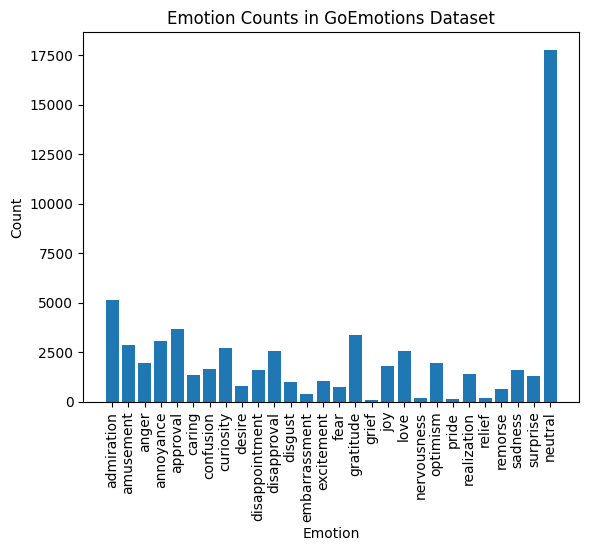

In [20]:
# plot a histogram of the emotion counts using matplotlib
import matplotlib.pyplot as plt
plt.bar(emotion_counts.keys(), emotion_counts.values())
plt.xticks(rotation=90)
plt.title("Emotion Counts in GoEmotions Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

This repeats the full emotion-count chart, again showing neutral as the dominant label.

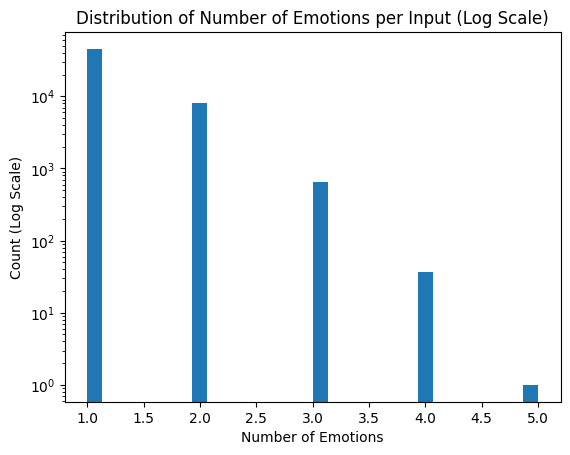

In [21]:
# logarithmic scale histogram of num_emotions column
plt.hist(goemotions_df['num_emotions'], bins=30, log=True)
plt.title("Distribution of Number of Emotions per Input (Log Scale)")
plt.xlabel("Number of Emotions")
plt.ylabel("Count (Log Scale)")
plt.show()

The log-scale histogram confirms that multi-emotion inputs are uncommon compared with single-emotion inputs.

In [22]:
# input with 5 labels

print(goemotions_df[goemotions_df['num_emotions'] == 5].iloc[0]['text'])

Yeah I probably would've started crying on the spot. Loud, sudden and especially shrill noises are extremely *"cringey"* and uncomfortable and stressful


This five-label example is emotionally dense, combining discomfort, stress, and sadness-related language.

In [23]:
# labels of goemotions_df[goemotions_df['num_emotions'] == 5].iloc[0]['text']

labels_5 = goemotions_df[goemotions_df['num_emotions'] == 5].iloc[0]['labels']
labels_5

array([ 9, 12, 14, 19, 25])

The labels are stored as integer IDs, so they must be decoded through `emotion_list` before interpretation.

In [24]:
# emotions for the five-label example
labels_5_names = [emotion_list[i] for i in labels_5]
labels_5_names

['disappointment', 'embarrassment', 'fear', 'nervousness', 'sadness']

The decoded labels for this example are disappointment, embarrassment, fear, nervousness, and sadness.

In [25]:
# number of combinations of emotions in goemotions_df

goemotions_df['emotion_list'] = goemotions_df.apply(lambda row: [emotion_list[i] for i in range(len(emotion_list)) if row[emotion_list[i]] == 1], axis=1)
goemotions_df['emotion_list'].value_counts()



emotion_list
[neutral]                                   16021
[admiration]                                 3384
[gratitude]                                  2378
[approval]                                   2367
[amusement]                                  2046
                                            ...  
[admiration, gratitude, nervousness]            1
[admiration, confusion, excitement, joy]        1
[confusion, joy, realization]                   1
[admiration, amusement, realization]            1
[amusement, optimism, neutral]                  1
Name: count, Length: 782, dtype: int64

There are 782 unique emotion combinations. The most common combinations are single-label cases, especially neutral, admiration, gratitude, approval, and amusement.

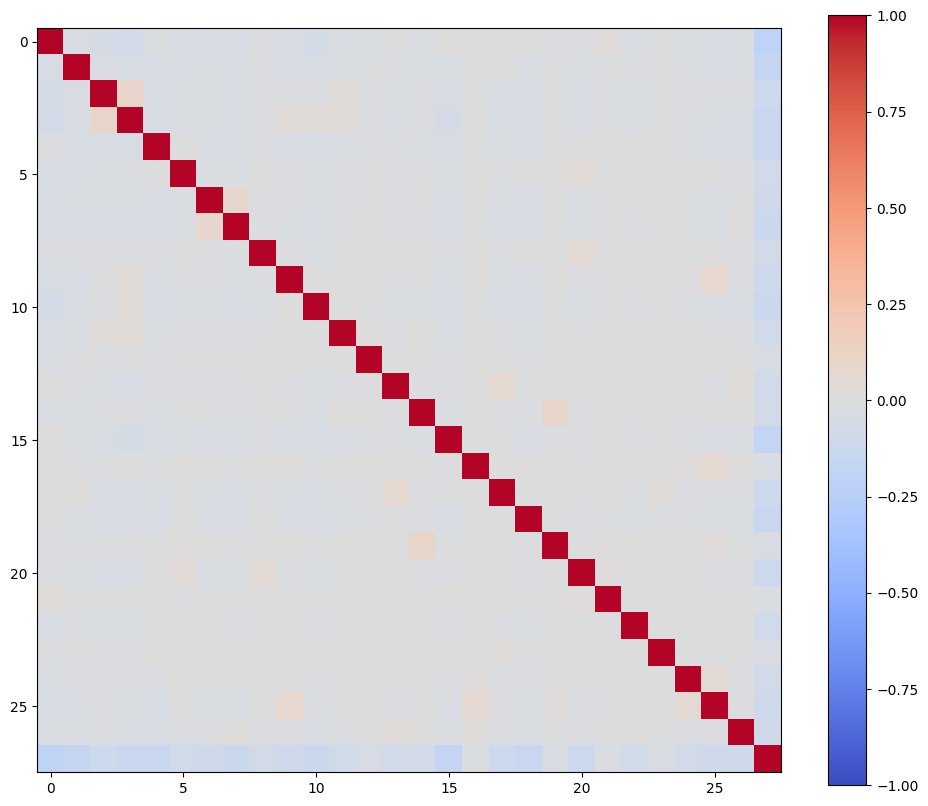

In [26]:
# correlation matrix of emotions in goemotions_df
correlation_matrix = goemotions_df[emotion_list].corr()
correlation_matrix

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

The full correlation heatmap is dominated by label sparsity and neutral examples, so strong relationships are hard to see.

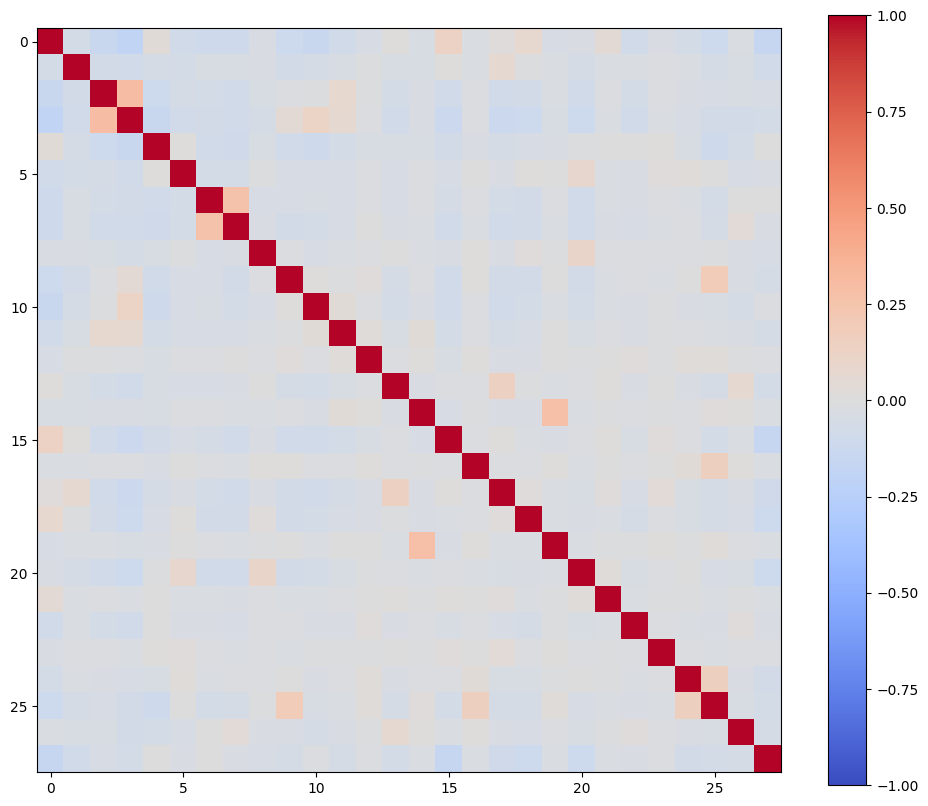

In [27]:
# correlation matrix of emotions in goemotions_df when num_emotions is greater than 1
correlation_matrix = goemotions_df[goemotions_df['num_emotions'] > 1][emotion_list].corr()
correlation_matrix

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

Filtering to multi-label rows makes co-occurrence patterns clearer because rows with only one active emotion are removed.

In [28]:
# number of words in the text column of goemotions_df
goemotions_df['num_words'] = goemotions_df['text'].apply(lambda x: len(x.split()))
goemotions_df.head()

,text,labels,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,pride,realization,relief,remorse,sadness,surprise,neutral,num_emotions,emotion_list,num_words
0,My favourite food is anything I didn't have to...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,[neutral],11
1,"Now if he does off himself, everyone will thin...",[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,[neutral],20
2,WHY THE FUCK IS BAYLESS ISOING,[2],0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,[anger],6
3,To make her feel threatened,[14],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,[fear],5
4,Dirty Southern Wankers,[3],0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,[annoyance],3


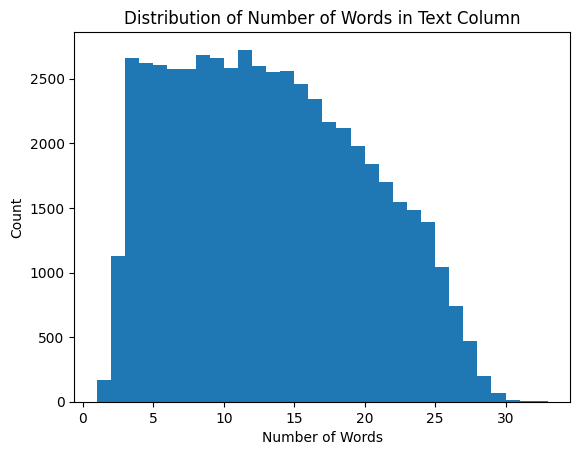

In [29]:
# analyze the distribution of number of words in the text column of goemotions_df
plt.hist(goemotions_df['num_words'], bins=32)
plt.title("Distribution of Number of Words in Text Column")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()


Most GoEmotions texts are short, with the distribution concentrated below 20 words.

In [30]:
# summary of num_words column
goemotions_df['num_words'].describe()

count    54263.000000
mean        12.823803
std          6.702950
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: num_words, dtype: float64

GoEmotions texts are short: the median is 12 words and 75% of examples have 18 words or fewer.

In [31]:
# number of characters in the text column of goemotions_df
goemotions_df['num_char'] = goemotions_df['text'].apply(lambda x: len(x))
goemotions_df.head()

,text,labels,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,realization,relief,remorse,sadness,surprise,neutral,num_emotions,emotion_list,num_words,num_char
0,My favourite food is anything I didn't have to...,[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,[neutral],11,59
1,"Now if he does off himself, everyone will thin...",[27],0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,[neutral],20,112
2,WHY THE FUCK IS BAYLESS ISOING,[2],0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,[anger],6,30
3,To make her feel threatened,[14],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[fear],5,27
4,Dirty Southern Wankers,[3],0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,[annoyance],3,22


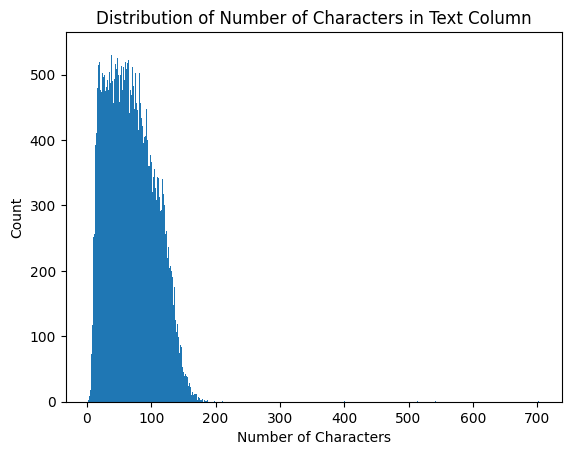

In [32]:
# analyze the distribution of number of characters in the text column of goemotions_df
plt.hist(goemotions_df['num_char'], bins=703)
plt.title("Distribution of Number of Characters in Text Column")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.show()

The character-length histogram is right-skewed: most texts are short, with a few very long outliers.

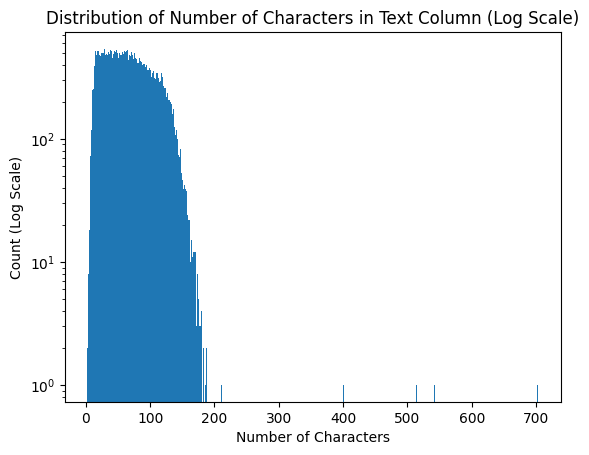

In [33]:
# analyze the distribution of number of characters in the text column of goemotions_df
plt.hist(goemotions_df['num_char'], bins=703, log=True)
plt.title("Distribution of Number of Characters in Text Column (Log Scale)")
plt.xlabel("Number of Characters")
plt.ylabel("Count (Log Scale)")
plt.show()

The log-scale version makes rare long-text outliers visible without hiding the dense short-text region.

In [34]:
goemotions_df['num_char'].describe()

count    54263.000000
mean        68.327553
std         36.700219
min          2.000000
25%         38.000000
50%         65.000000
75%         96.000000
max        703.000000
Name: num_char, dtype: float64

The median text length is 65 characters, but the maximum reaches 703 characters, indicating a few extreme outliers.

In [35]:
# five highest number of char
goemotions_df.nlargest(5, 'num_char')[['text', 'num_char']]


,text,num_char
2546,This person is the smartest person to play tow...,703
21639,For your kindness to mobile users I give a pla...,542
28694,here you go: |Games|Home|Away|Team|vs W-L 18-1...,514
28640,No the whippet sound is WUBWUBWUBWUBWUBWUBWUBW...,400
35488,Communism naturally results in dictatorship. W...,211


The longest examples include formatting-heavy posts, ASCII art, tables, and repeated characters.

In [36]:
# print the element with 703.000000 in the num_char column
goemotions_df[goemotions_df['num_char'] == 703.000000]

,text,labels,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,realization,relief,remorse,sadness,surprise,neutral,num_emotions,emotion_list,num_words,num_char
2546,This person is the smartest person to play tow...,[0],1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,[admiration],14,703


The largest outlier is labeled admiration and has only 14 words; its length comes from repeated characters.

In [37]:
print(goemotions_df[goemotions_df['num_char'] == 542.000000].iloc[0]['text'], "\n", goemotions_df[goemotions_df['num_char'] == 542.000000].iloc[0]['emotion_list'])

For your kindness to mobile users I give a platinum ⠀⠀⠀⠀⠀⣤⣶⣶⡶⠦⠴⠶⠶⠶⠶⡶⠶⠦⠶⠶⠶⠶⠶⠶⠶⣄⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⣿⣀⣀⣀⣀⠀⢀⣤⠄⠀⠀⣶⢤⣄⠀⠀⠀⣤⣤⣄⣿⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⠿⣿⣿⣿⣿⡷⠋⠁⠀⠀⠀⠙⠢⠙⠻⣿⡿⠿⠿⠫⠋⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⠀⢀⣤⠞⠉⠀⠀⠀⠀⣴⣶⣄⠀⠀⠀⢀⣕⠦⣀⠀⠀⠀⠀⠀⠀ ⠀⠀⠀⢀⣤⠾⠋⠁⠀⠀⠀⠀⢀⣼⣿⠟⢿⣆⠀⢠⡟⠉⠉⠊⠳⢤⣀⠀⠀⠀ ⠀⣠⡾⠛⠁⠀⠀⠀⠀⠀⢀⣀⣾⣿⠃⠀⡀⠹⣧⣘⠀⠀⠀⠀⠀⠀⠉⠳⢤⡀ ⠀⣿⡀⠀⠀⢠⣶⣶⣿⣿⣿⣿⡿⠁⠀⣼⠃⠀⢹⣿⣿⣿⣶⣶⣤⠀⠀⠀⢰⣷ ⠀⢿⣇⠀⠀⠈⠻⡟⠛⠋⠉⠉⠀⠀⡼⠃⠀⢠⣿⠋⠉⠉⠛⠛⠋⠀⢀⢀⣿⡏ ⠀⠘⣿⡄⠀⠀⠀⠈⠢⡀⠀⠀⠀⡼⠁⠀⢠⣿⠇⠀⠀⡀⠀⠀⠀⠀⡜⣼⡿⠀ ⠀⠀⢻⣷⠀⠀⠀⠀⠀⢸⡄⠀⢰⠃⠀⠀⣾⡟⠀⠀⠸⡇⠀⠀⠀⢰⢧⣿⠃⠀ ⠀⠀⠘⣿⣇⠀⠀⠀⠀⣿⠇⠀⠇⠀⠀⣼⠟⠀⠀⠀⠀⣇⠀⠀⢀⡟⣾⡟⠀⠀ ⠀⠀⠀⢹⣿⡄⠀⠀⠀⣿⠀⣀⣠⠴⠚⠛⠶⣤⣀⠀⠀⢻⠀⢀⡾⣹⣿⠃⠀⠀ ⠀⠀⠀⠀⢿⣷⠀⠀⠀⠙⠊⠁⠀⢠⡆⠀⠀⠀⠉⠛⠓⠋⠀⠸⢣⣿⠏⠀⠀⠀ ⠀⠀⠀⠀⠘⣿⣷⣦⣤⣤⣄⣀⣀⣿⣤⣤⣤⣤⣤⣄⣀⣀⣀⣀⣾⡟⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⢹⣿⣿⣿⣻⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠁⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⠀⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠛⠃ 
 ['neutral']


The 542-character neutral example is ASCII art, so length can reflect formatting rather than semantic content.

In [38]:
print(goemotions_df[goemotions_df['num_char'] == 514.000000].iloc[0]['text'], "\n", goemotions_df[goemotions_df['num_char'] == 514.000000].iloc[0]['emotion_list'])

here you go: |Games|Home|Away|Team|vs W-L 18-19| |:-|:-|:-|:-|-:| |1|1|0|Golden State|0-1| |2|1|1|Houston|0-0| |2|1|1|Oklahoma City|0-0| |2|0|2|Toronto|1-1| |2|1|1|Milwaukee|0-1| |3|1|2|Indiana|0-1| |2|1|1|Philadelphia|1-1| |2|1|1|Boston|1-0| |1|1|0|Minnesota|0-1| |2|1|1|New Orleans|0-0| |2|1|1|Memphis|0-0| |1|1|0|Dallas|0-1| |1|0|1|Miami|2-1| |3|2|1|Brooklyn|0-0| |2|1|1|Charlotte|0-2| |2|0|2|Detroit|1-1| |2|1|1|Washington|1-1| |2|1|1|New York|2-0| |2|1|1|Cleveland|1-0| |4|2|2|Atlanta|0-0| |1|1|0|Chicago|2-1| 
 ['neutral']


The 514-character neutral example is a markdown table, another formatting-driven outlier.

In [39]:
print(goemotions_df[goemotions_df['num_char'] == 211.000000].iloc[0]['text'], "\n", goemotions_df[goemotions_df['num_char'] == 211.000000].iloc[0]['emotion_list'])

Communism naturally results in dictatorship. When you centralize power, you invite the power-hungry. Every morally-motivated communist seems to think they're immune to the bullets of power-hungry totalitarians.  
 ['neutral']


The 211-character neutral example is closer to a normal long sentence than the previous formatting outliers.

In [40]:
print(goemotions_df[goemotions_df['num_char'] == 703.000000].iloc[0]['text'], "\n", goemotions_df[goemotions_df['num_char'] == 703.000000].iloc[0]['emotion_list'])

This person is the smartest person to play town of salem literally 999999999999999999999999999999999999999999999999999999999999999999999999999999999999999991000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001234567898765432345676543345678987654345678909876543234567898765432345678909876543234567898765432345678987654323456787654345676543456543456434543434343434323456765434567654323454323456543345678987654323456789876565656565656565656565656565454545654565454323456765432345678765456 IQ 
 ['admiration']


The 703-character outlier is mostly repeated digits, despite having only 14 words.

In [46]:
emotion_counts["neutral"]

np.int64(17772)

Neutral remains the dominant GoEmotions class with 17,772 examples.

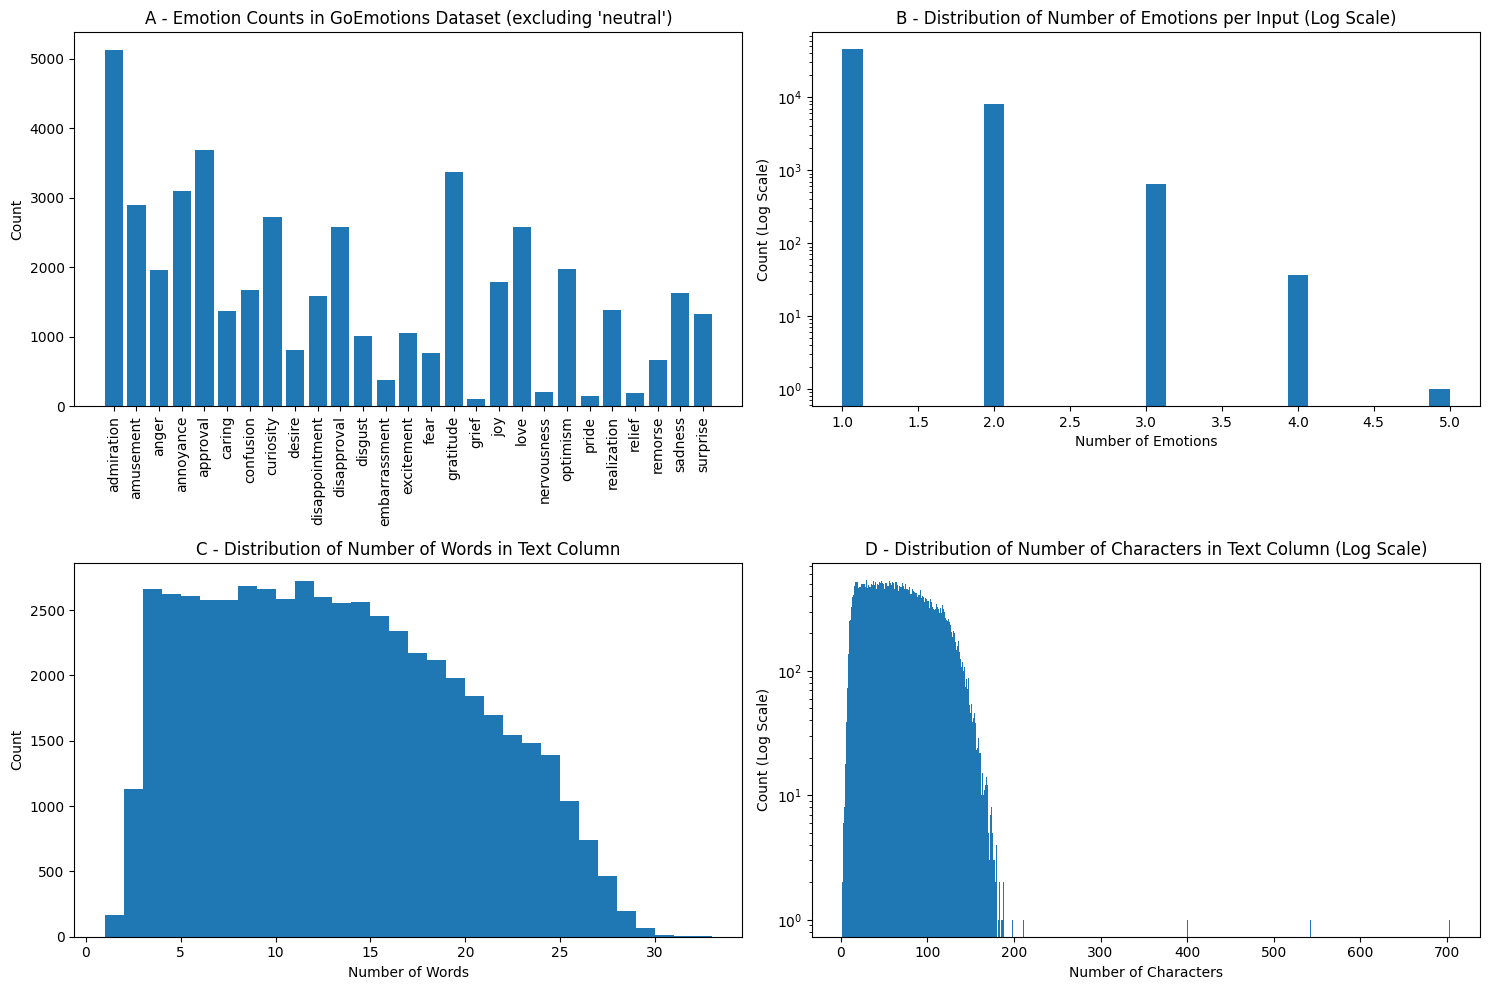

In [49]:
# put all the plots in a single figure with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
# --- IGNORE ---
# exclude neutral from emotion_counts
emotion_counts_excluding_neutral = {k: v for k, v in emotion_counts.items() if k != 'neutral'}
axs[0, 0].bar(emotion_counts_excluding_neutral.keys(), emotion_counts_excluding_neutral.values())
axs[0, 0].set_title("A - Emotion Counts in GoEmotions Dataset (excluding 'neutral')")
# on x axis rotate the labels 90 degrees
plt.setp(axs[0, 0].get_xticklabels(), rotation=90)
#axs[0, 0].set_xlabel("Emotion")
axs[0, 0].set_ylabel("Count")
# --- IGNORE ---
axs[0, 1].hist(goemotions_df['num_emotions'], bins=30, log=True)
axs[0, 1].set_title("B - Distribution of Number of Emotions per Input (Log Scale)")
axs[0, 1].set_xlabel("Number of Emotions")
axs[0, 1].set_ylabel("Count (Log Scale)")
# --- IGNORE ---
axs[1, 0].hist(goemotions_df['num_words'], bins=32)
axs[1, 0].set_title("C - Distribution of Number of Words in Text Column")
axs[1, 0].set_xlabel("Number of Words")
axs[1, 0].set_ylabel("Count")
# --- IGNORE ---
axs[1, 1].hist(goemotions_df['num_char'], bins=703, log=True)
axs[1, 1].set_title("D - Distribution of Number of Characters in Text Column (Log Scale)")
axs[1, 1].set_xlabel("Number of Characters")
axs[1, 1].set_ylabel("Count (Log Scale)")
plt.tight_layout()
plt.show()

Overall, GoEmotions is imbalanced, mostly single-label, and composed of short texts with a small number of character-length outliers.

# 2.  SemEval-2018 dataset

In [ ]:
#import urllib.request
#anger, fear, joy, or sadness
#url = "https://raw.githubusercontent.com/cbaziotis/ntua-slp-semeval2018/master/datasets/task1/EI-reg/EI-reg-En-sadness-train.txt"
#urllib.request.urlretrieve(url, "EI-reg-En-sadness-train.txt")

In [170]:
df_sad = pd.read_csv(r"data\SemEval-2018\EI-reg-En-sadness-train.txt", sep='\t')
df_sad.head()

,ID,Tweet,Affect Dimension,Intensity Score
0,2017-En-40023,This the most depressing shit ever,sadness,0.861
1,2017-En-40983,final vestiges of my 90's childhood were just ...,sadness,0.417
2,2017-En-20751,@ManUnitedWriter He has had a dreadful first h...,sadness,0.500
3,2017-En-41232,feel really sad and down today😒,sadness,0.833
4,2017-En-40797,Wow just watched Me Before You and it was seri...,sadness,0.667


In [181]:
df_sad.shape

(1533, 4)

The sadness split contains 1,533 training tweets.

In [171]:
df_fear = pd.read_csv(r"data\SemEval-2018\EI-reg-En-fear-train.txt", sep='\t')
df_fear.head()

,ID,Tweet,Affect Dimension,Intensity Score
0,2017-En-20968,@RockSolidShow @Pat_Francis #revolting cocks i...,fear,0.292
1,2017-En-21816,@Its_just_Huong I will beat you !!! Always tho...,fear,0.667
2,2017-En-21532,“What worries you masters you.” - Haddon Robin...,fear,0.604
3,2017-En-20740,@carlybigelow13 first you take the room now yo...,fear,0.412
4,2017-En-20022,@RogueCoder250 We are in so much trouble!! I d...,fear,0.896


In [180]:
df_fear.shape

(2252, 4)

The fear split is the largest of the four SemEval splits, with 2,252 tweets.

In [172]:
df_joy = pd.read_csv(r"data\SemEval-2018\EI-reg-En-joy-train.txt", sep='\t')
df_joy.head()

,ID,Tweet,Affect Dimension,Intensity Score
0,2017-En-30793,"@david_garrett Quite saddened.....no US dates,...",joy,0.140
1,2017-En-30070,2 days until #GoPackGo and 23 days until #GoGi...,joy,0.792
2,2017-En-30692,Positive #psychology research shows salespeopl...,joy,0.274
3,2017-En-31323,As the birds chirp and the cows moo we need to...,joy,0.480
4,2017-En-31553,Howling with laughter at “WELL DONE BEZZA!” #b...,joy,0.940


In [179]:
df_joy.shape

(1616, 4)

The joy split contains 1,616 training tweets.

In [173]:
df_anger = pd.read_csv(r"data\SemEval-2018\EI-reg-En-anger-train.txt", sep='\t')
df_anger.head()

,ID,Tweet,Affect Dimension,Intensity Score
0,2017-En-10264,@xandraaa5 @amayaallyn6 shut up hashtags are c...,anger,0.562
1,2017-En-10072,it makes me so fucking irate jesus. nobody is ...,anger,0.750
2,2017-En-11383,Lol Adam the Bull with his fake outrage...,anger,0.417
3,2017-En-11102,@THATSSHAWTYLO passed away early this morning ...,anger,0.354
4,2017-En-11506,@Kristiann1125 lol wow i was gonna say really?...,anger,0.438


In [178]:
df_anger.shape

(1701, 4)

The anger split contains 1,701 training tweets.

In [187]:
df_sem= pd.concat([df_sad, df_fear, df_joy, df_anger], ignore_index=True)
df_sem.shape

(7102, 4)

The merged SemEval training set has 7,102 tweets across sadness, fear, joy, and anger.

In [188]:
df_sem

,ID,Tweet,Affect Dimension,Intensity Score
0,2017-En-40023,This the most depressing shit ever,sadness,0.861
1,2017-En-40983,final vestiges of my 90's childhood were just ...,sadness,0.417
2,2017-En-20751,@ManUnitedWriter He has had a dreadful first h...,sadness,0.500
3,2017-En-41232,feel really sad and down today😒,sadness,0.833
4,2017-En-40797,Wow just watched Me Before You and it was seri...,sadness,0.667
...,...,...,...,...
7097,2017-En-11110,Got a $20 tip from a drunk Uber passenger. Tod...,anger,0.708
7098,2017-En-11497,@Claymakerbigsi @toghar11 @scott_mulligan_ @Bo...,anger,0.625
7099,2017-En-10539,@vladfucker69 i look rabid,anger,0.472
7100,2017-En-10468,"@m_t_f_72 I'm not surprised, I would be fuming! 😤",anger,0.479


In [189]:
df_sem.drop(columns=['ID'], inplace=True)
df_sem

,Tweet,Affect Dimension,Intensity Score
0,This the most depressing shit ever,sadness,0.861
1,final vestiges of my 90's childhood were just ...,sadness,0.417
2,@ManUnitedWriter He has had a dreadful first h...,sadness,0.500
3,feel really sad and down today😒,sadness,0.833
4,Wow just watched Me Before You and it was seri...,sadness,0.667
...,...,...,...
7097,Got a $20 tip from a drunk Uber passenger. Tod...,anger,0.708
7098,@Claymakerbigsi @toghar11 @scott_mulligan_ @Bo...,anger,0.625
7099,@vladfucker69 i look rabid,anger,0.472
7100,"@m_t_f_72 I'm not surprised, I would be fuming! 😤",anger,0.479


In [190]:
# list of emotions in Affect Dimension column of df_sem
emotions_sem = df_sem['Affect Dimension'].unique()
emotions_sem

<StringArray>
['sadness', 'fear', 'joy', 'anger']
Length: 4, dtype: str

SemEval contains four target emotions: sadness, fear, joy, and anger.

In [191]:
# add columns ANGER, FEAR, JOY, SADNESS to df_sem with 1 if the emotion in Affect Dimension column is the same as the column name, 0 otherwise
df_sem['anger'] = df_sem['Affect Dimension'].apply(lambda x: 1 if x == 'anger' else 0)
df_sem['fear'] = df_sem['Affect Dimension'].apply(lambda x: 1 if x == 'fear' else 0)
df_sem['joy'] = df_sem['Affect Dimension'].apply(lambda x: 1 if x == 'joy' else 0)
df_sem['sadness'] = df_sem['Affect Dimension'].apply(lambda x: 1 if x == 'sadness' else 0)
df_sem.head()

,Tweet,Affect Dimension,Intensity Score,anger,fear,joy,sadness
0,This the most depressing shit ever,sadness,0.861,0,0,0,1
1,final vestiges of my 90's childhood were just ...,sadness,0.417,0,0,0,1
2,@ManUnitedWriter He has had a dreadful first h...,sadness,0.500,0,0,0,1
3,feel really sad and down today😒,sadness,0.833,0,0,0,1
4,Wow just watched Me Before You and it was seri...,sadness,0.667,0,0,0,1


In [192]:
df_sem.drop(columns=['Affect Dimension'], inplace=True)

In [193]:
df_sem

,Tweet,Intensity Score,anger,fear,joy,sadness
0,This the most depressing shit ever,0.861,0,0,0,1
1,final vestiges of my 90's childhood were just ...,0.417,0,0,0,1
2,@ManUnitedWriter He has had a dreadful first h...,0.500,0,0,0,1
3,feel really sad and down today😒,0.833,0,0,0,1
4,Wow just watched Me Before You and it was seri...,0.667,0,0,0,1
...,...,...,...,...,...,...
7097,Got a $20 tip from a drunk Uber passenger. Tod...,0.708,1,0,0,0
7098,@Claymakerbigsi @toghar11 @scott_mulligan_ @Bo...,0.625,1,0,0,0
7099,@vladfucker69 i look rabid,0.472,1,0,0,0
7100,"@m_t_f_72 I'm not surprised, I would be fuming! 😤",0.479,1,0,0,0


In [194]:
# count the number of rows in df_sem where the emotion column is 1
emotions = ['anger', 'fear', 'joy', 'sadness']
emotion_counts = {}
for emotion in emotions:
    emotion_counts[emotion] = df_sem[emotion].sum()

emotion_counts

{'anger': np.int64(1701),
 'fear': np.int64(2252),
 'joy': np.int64(1616),
 'sadness': np.int64(1533)}

Fear is the largest SemEval class, followed by anger, joy, and sadness.

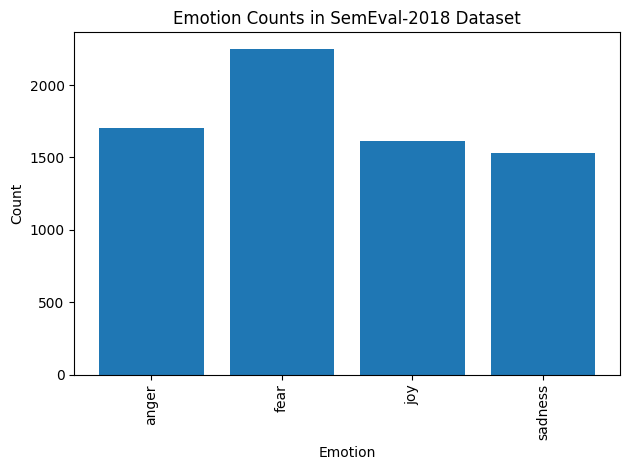

In [195]:
# plot a bar chart of SemEval emotion counts
import matplotlib.pyplot as plt
plt.bar(emotion_counts.keys(), emotion_counts.values())
plt.xticks(rotation=90)
plt.title("Emotion Counts in SemEval-2018 Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

The bar chart shows a milder imbalance than GoEmotions, with fear as the main majority class.

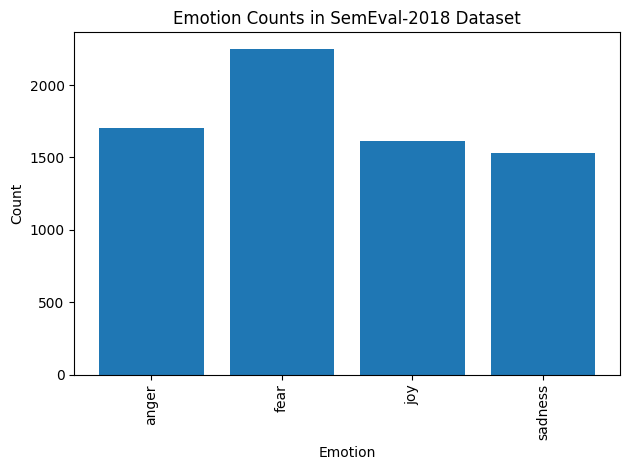

In [196]:
# plot a bar chart of SemEval emotion counts; no neutral class is present
emotion_counts_excluding_neutral = {k: v for k, v in emotion_counts.items() if k != 'neutral'}
plt.bar(emotion_counts_excluding_neutral.keys(), emotion_counts_excluding_neutral.values())
plt.xticks(rotation=90)
plt.title("Emotion Counts in SemEval-2018 Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

There is no neutral class in SemEval, so this plot is equivalent to the previous class-count chart.

In [197]:
# sort in descending order
emotion_counts_excluding_neutral_sorted = dict(sorted(emotion_counts_excluding_neutral.items(), key=lambda item: item[1], reverse=True))
emotion_counts_excluding_neutral_sorted

{'fear': np.int64(2252),
 'anger': np.int64(1701),
 'joy': np.int64(1616),
 'sadness': np.int64(1533)}

Sorted counts confirm the class order: fear, anger, joy, then sadness.

In [201]:
# number of words in the text column of df_sem
df_sem['num_words'] = df_sem['Tweet'].apply(lambda x: len(x.split()))
df_sem.head()

,Tweet,Intensity Score,anger,fear,joy,sadness,num_words
0,This the most depressing shit ever,0.861,0,0,0,1,6
1,final vestiges of my 90's childhood were just ...,0.417,0,0,0,1,25
2,@ManUnitedWriter He has had a dreadful first h...,0.500,0,0,0,1,25
3,feel really sad and down today😒,0.833,0,0,0,1,6
4,Wow just watched Me Before You and it was seri...,0.667,0,0,0,1,19


<Axes: >

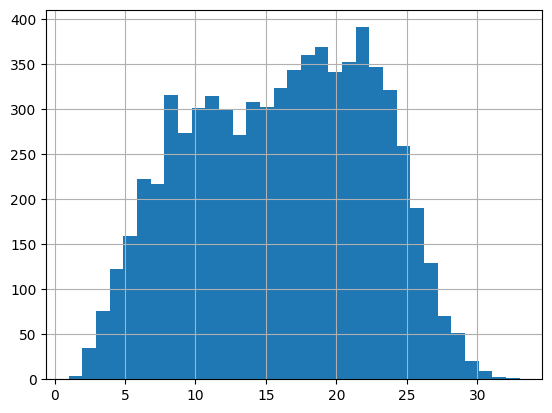

In [202]:
# analyze the distribution of number of words in the text column of df_sem
df_sem['num_words'].hist(bins=33)

Most SemEval tweets fall below 25 words, with a moderate spread across shorter tweet lengths.

In [204]:
# summary of num_words column
df_sem['num_words'].describe()

count    7102.000000
mean       16.080400
std         6.610378
min         1.000000
25%        11.000000
50%        17.000000
75%        22.000000
max        33.000000
Name: num_words, dtype: float64

SemEval tweets are longer than GoEmotions: the median is 17 words and the maximum is 33 words.

In [205]:
# number of characters in the text column of df_sem
df_sem['num_char'] = df_sem['Tweet'].apply(lambda x: len(x))
df_sem.head()

,Tweet,Intensity Score,anger,fear,joy,sadness,num_words,num_char
0,This the most depressing shit ever,0.861,0,0,0,1,6,34
1,final vestiges of my 90's childhood were just ...,0.417,0,0,0,1,25,135
2,@ManUnitedWriter He has had a dreadful first h...,0.500,0,0,0,1,25,139
3,feel really sad and down today😒,0.833,0,0,0,1,6,31
4,Wow just watched Me Before You and it was seri...,0.667,0,0,0,1,19,96


<Axes: >

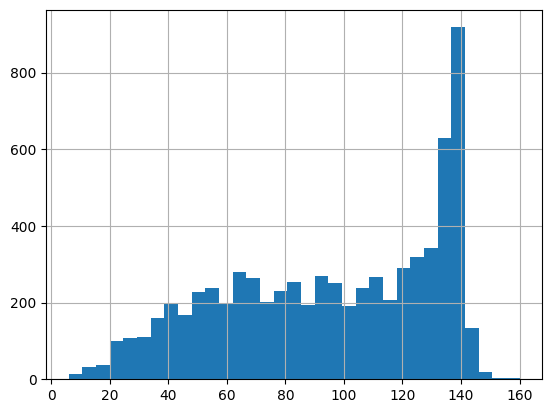

In [206]:
# analyze the distribution of number of characters in the text column of df_sem
df_sem['num_char'].hist(bins=33)

Character lengths cluster around medium-length tweets and stay within the expected tweet-length range.

In [208]:
# summary of num_char column
df_sem['num_char'].describe()

count    7102.000000
mean       95.250915
std        36.589539
min         6.000000
25%        65.000000
50%       100.000000
75%       131.000000
max       160.000000
Name: num_char, dtype: float64

Character lengths are tightly bounded, with a median of 100 characters and a maximum of 160.

In [210]:
# print the element with 160.000000 in the num_char column
df_sem[df_sem['num_char'] == 160.000000]

,Tweet,Intensity Score,anger,fear,joy,sadness,num_words,num_char
178,"When we are weak &amp; in despair, our Mighty ...",0.417,0,0,0,1,30,160


The longest SemEval example is a sadness tweet with 30 words and 160 characters.

In [211]:
print(df_sem[df_sem['num_char'] == 160.000000].iloc[0]['Tweet'])

When we are weak &amp; in despair, our Mighty God is near;He will give us strength &amp; joy &amp; hope, &amp; calm our inner fear, just have faith &amp; trust.


The longest SemEval tweet reaches the 160-character limit and contains sadness-related wording.